# Eigenvectors and Eigenvalues

## Overview

For a square matrix $A$, an **eigenvector** $\mathbf{v}$ and its corresponding **eigenvalue** $\lambda$ satisfy:

$$A \mathbf{v} = \lambda \mathbf{v}$$

### Intuition
- Most vectors change **both direction and magnitude** when multiplied by $A$
- An **eigenvector** only gets **scaled** — its direction stays the same (or flips 180°)
- The **eigenvalue** $\lambda$ is the scaling factor

### How to Find Them
1. Solve the **characteristic equation**: $\det(A - \lambda I) = 0$ to find eigenvalues $\lambda$
2. For each $\lambda$, solve $(A - \lambda I)\mathbf{v} = \mathbf{0}$ to find the eigenvector $\mathbf{v}$

## Step 1: Import Libraries

In [97]:
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Finding Eigenvalues and Eigenvectors

### 2×2 Example

$$A = \begin{bmatrix} 4 & 1 \\ 2 & 3 \end{bmatrix}$$

**Characteristic equation:**
$$\det(A - \lambda I) = (4 - \lambda)(3 - \lambda) - 2 = \lambda^2 - 7\lambda + 10 = 0$$
$$( \lambda - 5)(\lambda - 2) = 0 \implies \lambda_1 = 5, \quad \lambda_2 = 2$$

In [98]:
print('=' * 70)
print('FINDING EIGENVALUES AND EIGENVECTORS')
print('=' * 70)
print()

A = np.array([[4, 1],
              [2, 3]], dtype=float)

print('Matrix A:')
print(A)
print()

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print('Eigenvalues and Eigenvectors:')
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    print(f'  λ_{i+1} = {lam:.4f}, v_{i+1} = {v}')
print()

# Verify: A @ v = λ * v
print('Verification: A @ v = λ * v')
print('-' * 40)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av = A @ v
    lam_v = lam * v
    print(f'  A @ v_{i+1}   = {Av}')
    print(f'  λ_{i+1} * v_{i+1} = {lam_v}')
    print(f'  ✓ Match? {np.allclose(Av, lam_v)}')
    print()

FINDING EIGENVALUES AND EIGENVECTORS

Matrix A:
[[4. 1.]
 [2. 3.]]

Eigenvalues and Eigenvectors:
  λ_1 = 5.0000, v_1 = [0.70710678 0.70710678]
  λ_2 = 2.0000, v_2 = [-0.4472136   0.89442719]

Verification: A @ v = λ * v
----------------------------------------
  A @ v_1   = [3.53553391 3.53553391]
  λ_1 * v_1 = [3.53553391 3.53553391]
  ✓ Match? True

  A @ v_2   = [-0.89442719  1.78885438]
  λ_2 * v_2 = [-0.89442719  1.78885438]
  ✓ Match? True



## Step 3: Geometric Visualization

Eigenvectors maintain their direction under transformation by $A$.
All other vectors rotate.

GEOMETRIC VISUALIZATION



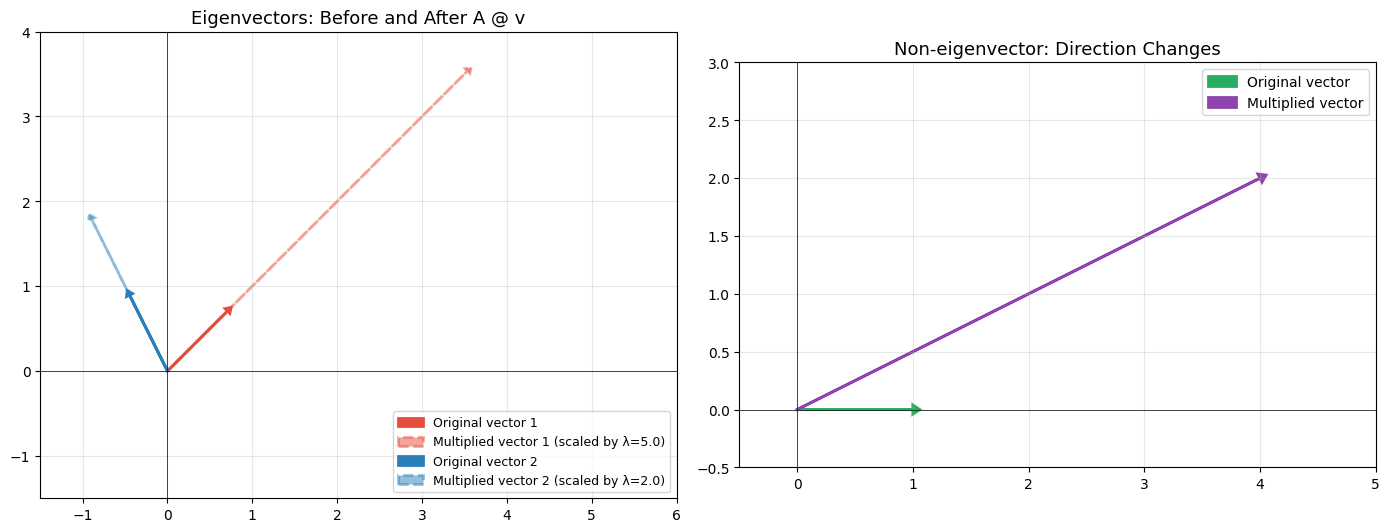

Left:  Eigenvectors only get scaled (same direction)
Right: A regular vector changes direction after transformation


In [99]:
print('=' * 70)
print('GEOMETRIC VISUALIZATION')
print('=' * 70)
print()

A = np.array([[4, 1],
              [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Eigenvectors before and after transformation
ax = axes[0]
ax.set_title('Eigenvectors: Before and After A @ v', fontsize=13)

colors = ['#e74c3c', '#2980b9']
for i in range(2):
    v = eigenvectors[:, i]
    Av = A @ v
    ax.arrow(0, 0, v[0], v[1], head_width=0.08, head_length=0.06,
             fc=colors[i], ec=colors[i], linewidth=2, label=f'Original vector {i+1}')
    ax.arrow(0, 0, Av[0], Av[1], head_width=0.08, head_length=0.06,
             fc=colors[i], ec=colors[i], linewidth=2, linestyle='dashed',
             alpha=0.5, label=f'Multiplied vector {i+1} (scaled by λ={eigenvalues[i]:.1f})')

ax.set_xlim(-1.5, 6)
ax.set_ylim(-1.5, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.legend(fontsize=9)

# Plot 2: A non-eigenvector changes direction
ax = axes[1]
ax.set_title('Non-eigenvector: Direction Changes', fontsize=13)

w = np.array([1, 0], dtype=float)  # Not an eigenvector
Aw = A @ w

ax.arrow(0, 0, w[0], w[1], head_width=0.08, head_length=0.06,
         fc='#27ae60', ec='#27ae60', linewidth=2, label='Original vector')
ax.arrow(0, 0, Aw[0], Aw[1], head_width=0.08, head_length=0.06,
         fc='#8e44ad', ec='#8e44ad', linewidth=2, label=f'Multiplied vector')

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print('Left:  Eigenvectors only get scaled (same direction)')
print('Right: A regular vector changes direction after transformation')

## Step 4: Eigendecomposition — Simplifying Matrix Powers

### Key Idea: Diagonalization

If $A$ has $n$ linearly independent eigenvectors, we can write:

$$A = P \Lambda P^{-1}$$

where:
- $P$ = matrix whose columns are eigenvectors of $A$
- $\Lambda$ = diagonal matrix of eigenvalues
- $P^{-1}$ = inverse of $P$

### Why This Simplifies Matrix Powers

$$A^k = (P \Lambda P^{-1})^k = P \Lambda^k P^{-1}$$

Raising a **diagonal** matrix to a power is trivial — just raise each diagonal element:

$$\Lambda^k = \begin{bmatrix} \lambda_1^k & 0 \\ 0 & \lambda_2^k \end{bmatrix}$$

This turns $O(k \cdot n^3)$ matrix multiplications into $O(n^3)$ — a **huge** speedup.

In [100]:
print('=' * 70)
print('EIGENDECOMPOSITION: A = P \u039b P^-1')
print('=' * 70)
print()

A = np.array([[4, 1],
              [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
diag_eigenvalues = np.diag(eigenvalues)
inv_eigenvectors = np.linalg.inv(eigenvectors)

print('Matrix A:')
print(A)
print()

print('P (eigenvectors as columns):')
print(eigenvectors)
print()

print('\u039b (diagonal matrix of eigenvalues):')
print(diag_eigenvalues)
print()

print('P^-1:')
print(inv_eigenvectors)
print()

# Verify: A = P @ \u039b @ P^-1
pow1_A = eigenvectors @ diag_eigenvalues @ inv_eigenvectors
print('Verification: P @ \u039b @ P^-1 =')
print(np.round(pow1_A, 10))
print()
print(f'\u2713 Equals A? {np.allclose(A, pow1_A)}')

EIGENDECOMPOSITION: A = P Λ P^-1

Matrix A:
[[4. 1.]
 [2. 3.]]

P (eigenvectors as columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Λ (diagonal matrix of eigenvalues):
[[5. 0.]
 [0. 2.]]

P^-1:
[[ 0.94280904  0.47140452]
 [-0.74535599  0.74535599]]

Verification: P @ Λ @ P^-1 =
[[4. 1.]
 [2. 3.]]

✓ Equals A? True


## Step 5: Simplifying Matrix Powers with Eigendecomposition

### Example: Compute $A^{10}$

**Brute force:** Multiply $A$ by itself 10 times = 9 matrix multiplications

**With eigendecomposition:** $A^{10} = P \Lambda^{10} P^{-1}$ = just raise diagonal entries to 10th power

In [101]:
print('=' * 70)
print('SIMPLIFYING MATRIX POWERS: A^k = P \u039b^k P^-1')
print('=' * 70)
print()

A = np.array([[4, 1],
              [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
diag_eigenvalues = np.diag(eigenvalues)
inv_eigenvectors = np.linalg.inv(eigenvectors)

for k in [2, 5, 10, 50]:
    # Method 1: Brute force - multiply A by itself k times
    pow_multiply = np.linalg.matrix_power(A, k)
    
    # Method 2: Using eigendecomposition - A^k = P @ \u039b^k @ P^-1
    diag_eigenvalues_k = np.diag(eigenvalues ** k)
    pow_eigen = eigenvectors @ diag_eigenvalues_k @ inv_eigenvectors
    
    match = np.allclose(pow_multiply, pow_eigen)
    
    print(f'A^{k}:')
    print(f'  Brute force:        {pow_multiply[0]}')
    print(f'                      {pow_multiply[1]}')
    print(f'  Eigendecomposition: {np.round(pow_eigen[0], 6)}')
    print(f'                      {np.round(pow_eigen[1], 6)}')
    print(f'  \u2713 Match? {match}')
    print()

print('Key insight: \u039b^k is trivial to compute since \u039b is diagonal')
print(f'  \u03bb_1 = {eigenvalues[0]:.1f} \u2192 \u03bb_1^10 = {eigenvalues[0]**10:.1f}')
print(f'  \u03bb_2 = {eigenvalues[1]:.1f} \u2192 \u03bb_2^10 = {eigenvalues[1]**10:.1f}')

SIMPLIFYING MATRIX POWERS: A^k = P Λ^k P^-1

A^2:
  Brute force:        [18.  7.]
                      [14. 11.]
  Eigendecomposition: [18.  7.]
                      [14. 11.]
  ✓ Match? True

A^5:
  Brute force:        [2094. 1031.]
                      [2062. 1063.]
  Eigendecomposition: [2094. 1031.]
                      [2062. 1063.]
  ✓ Match? True

A^10:
  Brute force:        [6510758. 3254867.]
                      [6509734. 3255891.]
  Eigendecomposition: [6510758. 3254867.]
                      [6509734. 3255891.]
  ✓ Match? True

A^50:
  Brute force:        [5.92118946e+34 2.96059473e+34]
                      [5.92118946e+34 2.96059473e+34]
  Eigendecomposition: [5.92118946e+34 2.96059473e+34]
                      [5.92118946e+34 2.96059473e+34]
  ✓ Match? True

Key insight: Λ^k is trivial to compute since Λ is diagonal
  λ_1 = 5.0 → λ_1^10 = 9765625.0
  λ_2 = 2.0 → λ_2^10 = 1024.0


## Step 6: Performance Comparison — Brute Force vs Eigendecomposition

For $A^k$ where $k$ is large, eigendecomposition is dramatically faster.

In [102]:
import time

print('=' * 70)
print('PERFORMANCE: BRUTE FORCE vs EIGENDECOMPOSITION')
print('=' * 70)
print()

n = 5
# Use a matrix with eigenvalues near 1 to avoid overflow at large k
np.random.seed(0)
A = np.eye(n) + 0.1 * np.random.randn(n, n)

eigenvalues, eigenvectors = np.linalg.eig(A)
inv_eigenvectors = np.linalg.inv(eigenvectors)

print(f'Matrix size: {n}x{n}')
print(f'Eigenvalues: {np.round(eigenvalues, 4)}')
print()

h1 = 'Power (k)'
h2 = 'Brute Force (s)'
h3 = 'Eigen Decomp (s)'
h4 = 'Speedup'
sep = ' | '
w1 = len(h1)
w2 = len(h2)
w3 = len(h3)
w4 = len(h4)

header = f'{h1:>{w1}}{sep}{h2:>{w2}}{sep}{h3:>{w3}}{sep}{h4:>{w4}}'
print(header)
print('-' * len(header))

for k in [10, 50, 100, 500, 1000]:
    # Brute force
    start = time.time()
    pow_multiply = np.linalg.matrix_power(A, k)
    time_brute = time.time() - start
    
    # Eigendecomposition
    start = time.time()
    diag_eigenvalues_k = np.diag(eigenvalues ** k)
    pow_eigne = eigenvectors @ diag_eigenvalues_k @ inv_eigenvectors
    time_eigen = time.time() - start
    
    speedup = time_brute / time_eigen if time_eigen > 0 else float('inf')
    row = f'{k:>{w1}d}{sep}{time_brute:>{w2}.6f}{sep}{time_eigen:>{w3}.6f}{sep}{speedup:>{w4}.1f}x'
    print(row)

print()
print('Note: Eigendecomposition cost is paid once (P and Λ are reused)')
print('For large k, brute force does k-1 multiplications while eigen does 1')

PERFORMANCE: BRUTE FORCE vs EIGENDECOMPOSITION

Matrix size: 5x5
Eigenvalues: [1.2291+0.2129j 1.2291-0.2129j 1.1391+0.j     1.0042+0.0384j
 1.0042-0.0384j]

Power (k) | Brute Force (s) | Eigen Decomp (s) | Speedup
--------------------------------------------------------
       10 |        0.000071 |         0.000050 |     1.4x
       50 |        0.000020 |         0.000012 |     1.7x
      100 |        0.000017 |         0.000014 |     1.2x
      500 |        0.000052 |         0.000011 |     4.6x
     1000 |        0.000028 |         0.000009 |     3.0x

Note: Eigendecomposition cost is paid once (P and Λ are reused)
For large k, brute force does k-1 multiplications while eigen does 1


## Step 7: Example — Fibonacci Numbers via Matrix Eigendecomposition

The Fibonacci sequence $F_n = F_{n-1} + F_{n-2}$ can be expressed as a matrix power:

$$\begin{bmatrix} F_{n+1} \\ F_n \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 1 & 0 \end{bmatrix}^n \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

Using eigendecomposition, we can compute $F_n$ **without iterating** through all previous values.

In [103]:
print('=' * 70)
print('FIBONACCI NUMBERS VIA EIGENDECOMPOSITION')
print('=' * 70)
print()

F = np.array([[1, 1],
              [1, 0]], dtype=float)

eigenvalues_f, eigenvectors_f = np.linalg.eig(F)
inv_eigenvectors_f = np.linalg.inv(eigenvectors_f)

print('Fibonacci matrix F:')
print(F)
print()
print(f'Eigenvalues: \u03bb_1 = {eigenvalues_f[0]:.6f} (golden ratio \u03c6)')
print(f'             \u03bb_2 = {eigenvalues_f[1]:.6f} (1 - \u03c6)')
print()

v0 = np.array([1, 0], dtype=float)

print('Fibonacci numbers using F^n @ [1, 0]:')
print('-' * 40)
for n in [5, 10, 15, 20, 30, 50]:
    # Using eigendecomposition: F^n = P @ \u039b^n @ P^-1
    diag_eigenvalues_n = np.diag(eigenvalues_f ** n)
    F_n = eigenvectors_f @ diag_eigenvalues_n @ inv_eigenvectors_f
    result = F_n @ v0
    fib_n = round(result[1])
    
    print(f'  F({n:>2d}) = {fib_n}')

print()
print('No loops needed \u2014 direct computation via eigenvalues!')

FIBONACCI NUMBERS VIA EIGENDECOMPOSITION

Fibonacci matrix F:
[[1. 1.]
 [1. 0.]]

Eigenvalues: λ_1 = 1.618034 (golden ratio φ)
             λ_2 = -0.618034 (1 - φ)

Fibonacci numbers using F^n @ [1, 0]:
----------------------------------------
  F( 5) = 5
  F(10) = 55
  F(15) = 610
  F(20) = 6765
  F(30) = 832040
  F(50) = 12586269025

No loops needed — direct computation via eigenvalues!


## Step 8: 3×3 Example

$$B = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 3 & 4 \\ 0 & 4 & 9 \end{bmatrix}$$

In [104]:
print('=' * 70)
print('3×3 EIGENVALUE EXAMPLE')
print('=' * 70)
print()

B = np.array([[2, 0, 0],
              [0, 3, 4],
              [0, 4, 9]], dtype=float)

print('Matrix B:')
print(B)
print()

eigenvalues_b, eigenvectors_b = np.linalg.eig(B)

print('Eigenvalues and Eigenvectors:')
for i in range(len(eigenvalues_b)):
    v = eigenvectors_b[:, i]
    lam = eigenvalues_b[i]
    print(f'  λ_{i+1} = {lam:.4f}, v_{i+1} = {np.round(v, 4)}')
print()

# Verify each eigenpair
print('Verification:')
print('-' * 40)
for i in range(len(eigenvalues_b)):
    v = eigenvectors_b[:, i]
    lam = eigenvalues_b[i]
    print(f'  B @ v_{i+1} = {np.round(B @ v, 4)}')
    print(f'  λ_{i+1} * v_{i+1} = {np.round(lam * v, 4)}')
    print(f'  ✓ Match? {np.allclose(B @ v, lam * v)}')
    print()

# Diagonalization: B^5
P_b = eigenvectors_b
P_b_inv = np.linalg.inv(P_b)

k = 5
B_power_brute = np.linalg.matrix_power(B, k)
diag_eigenvalues_k = np.diag(eigenvalues_b ** k)
B_power_eigen = P_b @ diag_eigenvalues_k @ P_b_inv

print(f'B^{k} (brute force):')
print(np.round(B_power_brute, 2))
print()
print(f'B^{k} (eigendecomposition):')
print(np.round(B_power_eigen, 2))
print()
print(f'✓ Match? {np.allclose(B_power_brute, B_power_eigen)}')

3×3 EIGENVALUE EXAMPLE

Matrix B:
[[2. 0. 0.]
 [0. 3. 4.]
 [0. 4. 9.]]

Eigenvalues and Eigenvectors:
  λ_1 = 11.0000, v_1 = [0.     0.4472 0.8944]
  λ_2 = 1.0000, v_2 = [ 0.      0.8944 -0.4472]
  λ_3 = 2.0000, v_3 = [1. 0. 0.]

Verification:
----------------------------------------
  B @ v_1 = [0.     4.9193 9.8387]
  λ_1 * v_1 = [0.     4.9193 9.8387]
  ✓ Match? True

  B @ v_2 = [ 0.      0.8944 -0.4472]
  λ_2 * v_2 = [ 0.      0.8944 -0.4472]
  ✓ Match? True

  B @ v_3 = [2. 0. 0.]
  λ_3 * v_3 = [2. 0. 0.]
  ✓ Match? True

B^5 (brute force):
[[3.20000e+01 0.00000e+00 0.00000e+00]
 [0.00000e+00 3.22110e+04 6.44200e+04]
 [0.00000e+00 6.44200e+04 1.28841e+05]]

B^5 (eigendecomposition):
[[3.20000e+01 0.00000e+00 0.00000e+00]
 [0.00000e+00 3.22110e+04 6.44200e+04]
 [0.00000e+00 6.44200e+04 1.28841e+05]]

✓ Match? True


## Step 9: Special Properties of Eigenvalues

Some useful properties that connect eigenvalues to matrix characteristics.

In [105]:
print('=' * 70)
print('EIGENVALUE PROPERTIES')
print('=' * 70)
print()

A = np.array([[4, 1],
              [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print('Matrix A:')
print(A)
print()

print('Eigenvalues and Eigenvectors:')
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    print(f'  λ_{i+1} = {lam:.4f}, v_{i+1} = {v}')
print()

# Property 1: trace = sum of eigenvalues
trace_A = np.trace(A)
sum_eigenvalues = np.sum(eigenvalues)
print(f'Property 1: trace(A) = sum of eigenvalues')
print(f'  trace(A) = {trace_A:.4f}')
print(f'  λ_1 + λ_2 = {sum_eigenvalues:.4f}')
print(f'  ✓ Match? {np.isclose(trace_A, sum_eigenvalues)}')
print()

# Property 2: determinant = product of eigenvalues
det_A = np.linalg.det(A)
prod_eigenvalues = np.prod(eigenvalues)
print(f'Property 2: det(A) = product of eigenvalues')
print(f'  det(A) = {det_A:.4f}')
print(f'  λ_1 × λ_2 = {prod_eigenvalues:.4f}')
print(f'  ✓ Match? {np.isclose(det_A, prod_eigenvalues)}')
print()

# Property 3: A is invertible iff no eigenvalue is 0
print(f'Property 3: A is invertible ⟺ no eigenvalue is 0')
print(f'  Eigenvalues: {eigenvalues}')
print(f'  Any zero? {np.any(np.isclose(eigenvalues, 0))}')
print(f'  ✓ A is invertible? {not np.any(np.isclose(eigenvalues, 0))}')
print()

# Property 4: eigenvalues of A^-1 are 1/λ
inv_A = np.linalg.inv(A)
eigenvalues_inv, eigenvectors_inv = np.linalg.eig(inv_A)
eigenvalues_inv_expected = 1.0 / eigenvalues
print(f'Property 4: eigenvalues of A^-1 are 1/λ')
print(f'  Eigenvalues of A:   {eigenvalues}')
print(f'  1/λ:                {eigenvalues_inv_expected}')
print(f'  Eigenvalues of A^-1: {np.sort(eigenvalues_inv)[::-1]}')
print(f'  ✓ Match? {np.allclose(np.sort(eigenvalues_inv_expected), np.sort(eigenvalues_inv))}')
print()

print('Eigenvalues and Eigenvectors of A^-1:')
for i in range(len(eigenvalues_inv)):
    v = eigenvectors_inv[:, i]
    lam = eigenvalues_inv[i]
    print(f'  λ_{i+1} = {lam:.4f}, v_{i+1} = {v}')

EIGENVALUE PROPERTIES

Matrix A:
[[4. 1.]
 [2. 3.]]

Eigenvalues and Eigenvectors:
  λ_1 = 5.0000, v_1 = [0.70710678 0.70710678]
  λ_2 = 2.0000, v_2 = [-0.4472136   0.89442719]

Property 1: trace(A) = sum of eigenvalues
  trace(A) = 7.0000
  λ_1 + λ_2 = 7.0000
  ✓ Match? True

Property 2: det(A) = product of eigenvalues
  det(A) = 10.0000
  λ_1 × λ_2 = 10.0000
  ✓ Match? True

Property 3: A is invertible ⟺ no eigenvalue is 0
  Eigenvalues: [5. 2.]
  Any zero? False
  ✓ A is invertible? True

Property 4: eigenvalues of A^-1 are 1/λ
  Eigenvalues of A:   [5. 2.]
  1/λ:                [0.2 0.5]
  Eigenvalues of A^-1: [0.5 0.2]
  ✓ Match? True

Eigenvalues and Eigenvectors of A^-1:
  λ_1 = 0.2000, v_1 = [-0.70710678 -0.70710678]
  λ_2 = 0.5000, v_2 = [ 0.4472136  -0.89442719]


## Step 10: Use Cases for Eigenvalues and Eigenvectors

### Machine Learning and Data Science
| Use Case | How Eigenvalues/Eigenvectors Help |
|---|---|
| **PCA (Principal Component Analysis)** | Eigenvectors of the covariance matrix give the principal directions of maximum variance; eigenvalues indicate how much variance each component captures |
| **Spectral Clustering** | Eigenvectors of the graph Laplacian matrix reveal cluster structure in data |
| **Recommender Systems (SVD)** | SVD (closely related to eigen-decomposition) decomposes user-item matrices for collaborative filtering |
| **Latent Semantic Analysis** | Eigenvectors extract hidden topic structure from document-term matrices |

### Physics and Engineering
| Use Case | How Eigenvalues/Eigenvectors Help |
|---|---|
| **Vibration Analysis** | Eigenvalues = natural frequencies; eigenvectors = mode shapes of vibrating structures |
| **Quantum Mechanics** | Eigenvalues of the Hamiltonian operator = energy levels; eigenvectors = quantum states |
| **Stability Analysis** | Eigenvalues of the system matrix determine if a dynamical system is stable (all eigenvalues have negative real parts) |
| **Stress/Strain (Structural Engineering)** | Principal stresses and their directions are eigenvalues and eigenvectors of the stress tensor |

### Graph Theory and Networks
| Use Case | How Eigenvalues/Eigenvectors Help |
|---|---|
| **Google PageRank** | The dominant eigenvector of the web's link matrix gives page importance rankings |
| **Community Detection** | Eigenvectors of adjacency/Laplacian matrices reveal communities in social networks |
| **Network Robustness** | Spectral gap (difference between largest eigenvalues) measures how well-connected a network is |

### Image Processing and Computer Vision
| Use Case | How Eigenvalues/Eigenvectors Help |
|---|---|
| **Face Recognition (Eigenfaces)** | Eigenvectors of face image covariance matrix form a basis for face space |
| **Image Compression** | Keep only top-$k$ eigenvectors to compress images with minimal quality loss |
| **Edge Detection** | Eigenvalues of the structure tensor detect corners and edges |

### Other Applications
| Use Case | How Eigenvalues/Eigenvectors Help |
|---|---|
| **Markov Chains** | Steady-state distribution is the eigenvector for eigenvalue 1 of the transition matrix |
| **Differential Equations** | Solutions of linear ODE systems $\mathbf{x'} = A\mathbf{x}$ are built from eigenvalues and eigenvectors of $A$ |
| **Matrix Powers / Fibonacci** | Eigendecomposition turns $A^k$ into simple scalar exponentiations (as shown above) |
| **Condition Number** | Ratio of largest to smallest eigenvalue measures numerical sensitivity |

## Step 11: PCA Demo — Eigenvalues in Action

A quick demonstration of how eigenvectors reveal the principal directions in 2D data.

PCA DEMO: EIGENVECTORS OF COVARIANCE MATRIX

Covariance matrix of the data:
[[2.7354 1.8405]
 [1.8405 1.3944]]

Eigenvalues (variance along each principal direction):
  λ_1 = 4.0237 (97.4% of total variance)
  λ_2 = 0.1061 (2.6% of total variance)

Eigenvectors (principal directions):
  PC_1 = [0.8192 0.5735]
  PC_2 = [-0.5735  0.8192]



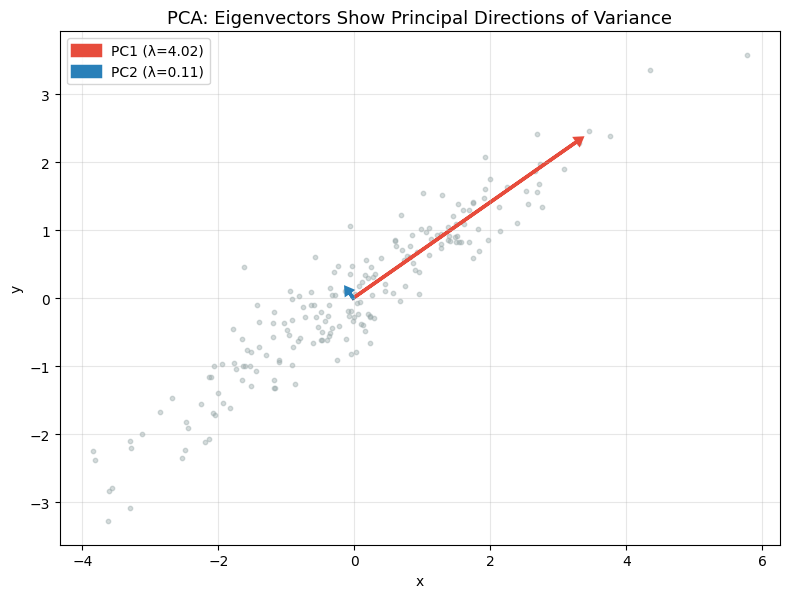

Red arrow:  Direction of maximum variance (PC1)
Blue arrow: Direction of minimum variance (PC2)
Arrow length is proportional to the eigenvalue (variance)


In [106]:
print('=' * 70)
print('PCA DEMO: EIGENVECTORS OF COVARIANCE MATRIX')
print('=' * 70)
print()

np.random.seed(42)

# Generate correlated 2D data
mean = [0, 0]
cov = [[3, 2],
       [2, 1.5]]
data = np.random.multivariate_normal(mean, cov, 200)

# Compute covariance matrix
cov_matrix = np.cov(data.T)
print('Covariance matrix of the data:')
print(np.round(cov_matrix, 4))
print()

# Eigendecomposition of covariance matrix
eigenvalues_pca, eigenvectors_pca = np.linalg.eig(cov_matrix)

print('Eigenvalues (variance along each principal direction):')
for i, val in enumerate(eigenvalues_pca):
    pct = val / sum(eigenvalues_pca) * 100
    print(f'  \u03bb_{i+1} = {val:.4f} ({pct:.1f}% of total variance)')
print()

print('Eigenvectors (principal directions):')
for i in range(2):
    print(f'  PC_{i+1} = {np.round(eigenvectors_pca[:, i], 4)}')
print()

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.scatter(data[:, 0], data[:, 1], alpha=0.4, s=10, color='#95a5a6')

origin = np.mean(data, axis=0)
colors = ['#e74c3c', '#2980b9']
for i in range(2):
    v = eigenvectors_pca[:, i] * eigenvalues_pca[i]
    ax.arrow(origin[0], origin[1], v[0], v[1],
             head_width=0.1, head_length=0.08,
             fc=colors[i], ec=colors[i], linewidth=2.5,
             label=f'PC{i+1} (\u03bb={eigenvalues_pca[i]:.2f})')

ax.set_title('PCA: Eigenvectors Show Principal Directions of Variance', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Red arrow:  Direction of maximum variance (PC1)')
print('Blue arrow: Direction of minimum variance (PC2)')
print('Arrow length is proportional to the eigenvalue (variance)')

## Summary

### Key Concepts

1. **Eigenvectors and Eigenvalues**
   - $A\mathbf{v} = \lambda\mathbf{v}$: eigenvectors only get scaled, not rotated
   - Found by solving the characteristic equation $\det(A - \lambda I) = 0$

2. **Eigendecomposition: $A = P\Lambda P^{-1}$**
   - $P$ = eigenvector matrix, $\Lambda$ = diagonal eigenvalue matrix
   - Simplifies matrix powers: $A^k = P\Lambda^k P^{-1}$
   - Diagonal powers are trivial: just raise each $\lambda_i$ to the $k$-th power

3. **Eigenvalue Properties**
   - $\text{trace}(A) = \sum \lambda_i$
   - $\det(A) = \prod \lambda_i$
   - $A$ is invertible $\iff$ no $\lambda_i = 0$
   - Eigenvalues of $A^{-1}$ are $1/\lambda_i$

4. **Applications**
   - **PCA**: Eigenvectors of covariance matrix = principal directions
   - **PageRank**: Dominant eigenvector = page importance
   - **Stability**: Eigenvalue signs determine system behavior
   - **Matrix Powers**: Eigendecomposition avoids repeated multiplication